**Статья** https://pubs.rsc.org/en/content/articlehtml/2026/dd/d5dd00440c (Публикация 25 февраля 2026)

Our implementation code, pre-trained models, and processed datasets are permanently archived on Zenodo at https://doi.org/10.5281/zenodo.18232614.

In [ ]:
# Пункт 0  версии torch и cuda
import torch
print(torch.__version__)
print(torch.version.cuda)

2.10.0+cu128
12.8


In [ ]:
# Пункт 1 — Установка зависимостей
# torch-geometric ставим напрямую
!pip install torch-geometric

# torch-scatter и torch-sparse — берём ближайший совместимый wheel (cu121 работает с cu128)
!pip install torch-scatter torch-sparse torch-cluster \
    -f https://data.pyg.org/whl/torch-2.1.0+cu121.html

!pip install rdkit easydict pyyaml lmdb biopython


Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html
  Using cached torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl
  Using cached torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl
  Using cached torch_cluster-1.6.3.tar.gz (54 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for torch-cluster: filename=torch_cluster-1.6.3-cp312-cp312-linux_x86_64.whl size=2242565 sha256=f0d60d3a3db08ec5c34eb643739c988e80839c1fbbcd9eb80c46006f5e3501e0
  Stored in directory: /root/.cache/pip/wheels/2e/8f/d0/13408a84825c9a587151a74727b4a6d47ec67e0d625b385ad7
Successfully built torch-cluster
  Using cached rdkit-2025.9.6-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached lmdb-1.8.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (1.4 kB)
  Using cached biopython-1.86-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
Using cached rdkit-2025.9.6-cp312-cp312-manylinux_2_28_x86

In [ ]:
!apt-get install -y openbabel
!pip install openbabel-wheel


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libboost-iostreams1.74.0 libinchi1 libmaeparser1 libopenbabel7
The following NEW packages will be installed:
  libboost-iostreams1.74.0 libinchi1 libmaeparser1 libopenbabel7 openbabel
0 upgraded, 5 newly installed, 0 to remove and 37 not upgraded.
Need to get 4,148 kB of archives.
After this operation, 19.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libboost-iostreams1.74.0 amd64 1.74.0-14ubuntu3 [245 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libinchi1 amd64 1.03+dfsg-4 [455 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libmaeparser1 amd64 1.2.4-1build1 [88.2 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenbabel7 amd64 3.1.1+dfsg-6ubuntu5 [3,231 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy/universe amd64 openbabel am

In [ ]:
# Пункт 2 Загрузка файлов
from google.colab import drive
drive.mount('/content/drive')

import os

# Копируем всю папку проекта с Drive в Colab
!cp -r "/content/drive/MyDrive/ExpDiff-main/ExpDiff-main" /content/ExpDiff-main

# Копируем чекпоинт в нужную папку logs/
!mkdir -p /content/ExpDiff-main/logs
!cp "/content/drive/MyDrive/ExpDiff-main/ExpDiff-main/checkpoints/762000.pt" \
    /content/ExpDiff-main/logs/762000.pt

# Переходим в корень проекта
os.chdir('/content/ExpDiff-main')

# Проверка
assert os.path.exists('./logs/762000.pt'), " Чекпоинт не найден!"
print("✓ Чекпоинт найден:", os.path.getsize('./logs/762000.pt') // 1024, "KB")
print("✓ Файлы проекта:", os.listdir('.'))
print("✓ Тестовые белки:", os.listdir('./test_complex/other_pdb/'))



Mounted at /content/drive
✓ Чекпоинт найден: 33188 KB
✓ Файлы проекта: ['datasets', 'scripts', 'utils', 'test_complex', 'img', 'checkpoints', 'models', 'README.md', 'logs', 'configs', 'environment.yml']
✓ Тестовые белки: ['5liu_X_rec_4gq0_qap_lig_tt_min_0.sdf', '5liu_X_rec_pocket10.pqr', '5liu_X_rec_pocket10.pdbqt', '5liu_X_rec.pdb', '5liu_X_rec_pocket10.log', '5liu_X_rec_pocket10.pdb']


In [ ]:
# Пункт 3 — Проверка окружения и импортов

In [ ]:
import sys
import os
sys.path.insert(0, '/content/ExpDiff-main')
os.chdir('/content/ExpDiff-main')

import torch
import utils.misc as misc
import utils.transforms as trans
from models.molopt_score_model import ScorePosNet3D

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✓ Устройство: {device}")

#  Добавили weights_only=False
ckpt = torch.load('./logs/762000.pt', map_location=device, weights_only=False)
print(f"✓ Чекпоинт загружен. Шаг обучения: 762000")
print(f"  Режим кодирования атомов: {ckpt['config'].data.transform.ligand_atom_mode}")
print(f"  Параметры модели: {sum(p.numel() for p in ckpt['model'].values()):,}")


✓ Устройство: cuda
✓ Чекпоинт загружен. Шаг обучения: 762000
  Режим кодирования атомов: add_aromatic
  Параметры модели: 2,915,825


In [ ]:
# Пункт 3.5 — патчим

# 1. sascorer.py — убираем rdkit.six
!sed -i 's/from rdkit.six.moves import cPickle/import pickle as cPickle/' \
    /content/ExpDiff-main/utils/evaluation/sascorer.py
!sed -i 's/from rdkit.six import iteritems//' \
    /content/ExpDiff-main/utils/evaluation/sascorer.py
!sed -i 's/iteritems(/items(/' \
    /content/ExpDiff-main/utils/evaluation/sascorer.py

# 2. docking_vina.py — убираем все докинг зависимости
!sed -i '/from openbabel/s/^/# /' /content/ExpDiff-main/utils/evaluation/docking_vina.py
!sed -i '/from vina/s/^/# /'      /content/ExpDiff-main/utils/evaluation/docking_vina.py
!sed -i '/import vina/s/^/# /'    /content/ExpDiff-main/utils/evaluation/docking_vina.py
!sed -i '/import AutoDockTools/s/^/# /' /content/ExpDiff-main/utils/evaluation/docking_vina.py
!sed -i '/from meeko/s/^/# /'     /content/ExpDiff-main/utils/evaluation/docking_vina.py
!sed -i '/import meeko/s/^/# /'   /content/ExpDiff-main/utils/evaluation/docking_vina.py

# 3. data.py — патч numpy
!sed -i 's/np\.compat\.long/np.int64/g' /content/ExpDiff-main/utils/data.py

# 4. sample_from_complex.py — weights_only и map_location для GPU
!sed -i "s/map_location=args.device/map_location='cuda'/g" \
    /content/ExpDiff-main/scripts/sample_from_complex.py
!sed -i "s/torch\.load(config\.model\['joint_ckpt'\].*)/torch.load(config.model['joint_ckpt'], map_location='cuda', weights_only=False)/g" \
    /content/ExpDiff-main/scripts/sample_from_complex.py

# 5. Восстанавливаем полные шаги для GPU
!sed -i 's/num_steps: .*/num_steps: 1000/' /content/ExpDiff-main/configs/sampling.yml
!sed -i 's/num_samples: .*/num_samples: 4/' /content/ExpDiff-main/configs/sampling.yml

# Проверка
print("=== sampling.yml ===")
!cat /content/ExpDiff-main/configs/sampling.yml
print("\n=== torch.load в скрипте ===")
!grep -n "torch.load" /content/ExpDiff-main/scripts/sample_from_complex.py
print("\n=== numpy в data.py ===")
!grep -n "compat" /content/ExpDiff-main/utils/data.py || echo "✓ Чисто"
print("\n✓ Все патчи применены!")
# 6. Исправляем torch.load в evaluate_data (строка 63)
!sed -i 's/r = torch.load(r_name)/r = torch.load(r_name, weights_only=False)/g' \
    /content/ExpDiff-main/scripts/sample_from_complex.py

# Проверка
!grep -n "torch.load" /content/ExpDiff-main/scripts/sample_from_complex.py
# Исправляем ZeroDivisionError в eval_atom_type.py
!sed -i 's/pred_atom_distribution\[k\] = pred_counter\[k\] \/ total_num_atoms/pred_atom_distribution[k] = pred_counter[k] \/ total_num_atoms if total_num_atoms > 0 else 0/g' \
    /content/ExpDiff-main/utils/evaluation/eval_atom_type.py

# Проверка
!grep -n "total_num_atoms" /content/ExpDiff-main/utils/evaluation/eval_atom_type.py





=== sampling.yml ===
model:
  joint_ckpt: './logs/762000.pt'

sample:
  seed: 2025
  num_samples: 4
  num_steps: 1000
  pos_only: False
  center_pos_mode: protein
  sample_num_atoms: prior



=== torch.load в скрипте ===
63:        r = torch.load(r_name, weights_only=False)  # ['data', 'pred_ligand_pos', 'pred_ligand_v', 'pred_ligand_pos_traj', 'pred_ligand_v_traj']
203:    ckpt = torch.load(config.model['joint_ckpt'], map_location='cuda', weights_only=False)

=== numpy в data.py ===
✓ Чисто

✓ Все патчи применены!
63:        r = torch.load(r_name, weights_only=False)  # ['data', 'pred_ligand_pos', 'pred_ligand_v', 'pred_ligand_pos_traj', 'pred_ligand_v_traj']
203:    ckpt = torch.load(config.model['joint_ckpt'], map_location='cuda', weights_only=False)
28:    total_num_atoms = sum(pred_counter.values())
31:        pred_atom_distribution[k] = pred_counter[k] / total_num_atoms if total_num_atoms > 0 else 0


In [ ]:
# sampling.yml уже содержит:
#   joint_ckpt: './logs/762000.pt'
#   num_samples: 4
#   num_steps: 1000

# Генерация для белка 5LIU (AKT1 киназа) из test_complex
# Ячейка 4 — Запуск генерации
import os
os.chdir('/content/ExpDiff-main')

!PYTHONPATH=/content/ExpDiff-main python scripts/sample_from_complex.py \
    --protein_root ./test_complex/other_pdb/ \
    --protein_fn   5liu_X_rec.pdb \
    --ligand_fn    5liu_X_rec_4gq0_qap_lig_tt_min_0.sdf \
    --config       ./configs/sampling.yml \
    --device       cuda \
    --batch_size   2 \
    --result_path  ./results \
    --docking_mode none \
    --guide_mode   joint \
    --re_sample    False \
    --type_grad_weight 100 \
    --pos_grad_weight  25



[2026-03-15 21:36:21,392::sampling::INFO] {'model': {'joint_ckpt': './logs/762000.pt'}, 'sample': {'seed': 2025, 'num_samples': 4, 'num_steps': 1000, 'pos_only': False, 'center_pos_mode': 'protein', 'sample_num_atoms': 'prior'}}
[2026-03-15 21:36:22,020::sampling::INFO] Training Config: {'data': {'name': 'pl', 'path': './data/crossdocked_v1.1_rmsd1.0_pocket10', 'split': './data/crossdocked_pocket10_pose_split.pt', 'transform': {'ligand_atom_mode': 'add_aromatic', 'random_rot': False}}, 'model': {'model_mean_type': 'C0', 'beta_schedule': 'sigmoid', 'beta_start': 1e-07, 'beta_end': 0.002, 'v_beta_schedule': 'cosine', 'v_beta_s': 0.01, 'num_diffusion_timesteps': 1000, 'loss_v_weight': 100.0, 'loss_exp_weight': 1.0, 'sample_time_method': 'symmetric', 'affinity_with_diffusion': False, 'use_classifier_guide': True, 'time_emb_dim': 0, 'time_emb_mode': 'simple', 'center_pos_mode': 'protein', 'node_indicator': True, 'model_type': 'uni_o2', 'num_blocks': 1, 'num_layers': 9, 'hidden_dim': 128, 'n

In [ ]:
# Пункт5 — Визуализация полученных молекул

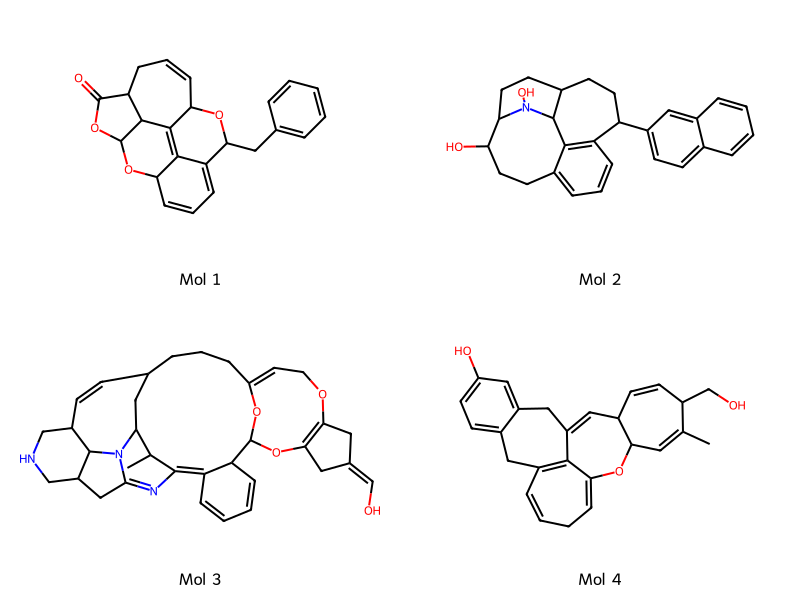

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

smiles_list = [
    "O=C1OC2OC3C=CC=C4C3=C3C(C=CCC1C32)OC4Cc1ccccc1",
    "OC1CCc2cccc3c2C2C(CCC3c3ccc4ccccc4c3)CCC1N2O",
    "CC1C2=C3C=CC=CC3C3OC(=CCOC4=C(CC(=CO)C4)O3)CCCC3C=CC4CNCC5CC(=N2)N(C1C3)C45",
    "CC1=CC2OC3=CCC=CC4=C3C(=CC2C=CC1CO)Cc1cc(O)ccc1C4"
]

mols = [Chem.MolFromSmiles(s) for s in smiles_list]
img = Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(400,300),
                           legends=[f"Mol {i+1}" for i in range(4)])

# Исправление — сохраняем через PIL
from PIL import Image
import io
png_data = img.data  # получаем байты
with open("molecules.png", "wb") as f:
    f.write(png_data)

# Показываем в ноутбуке
from IPython.display import display
display(img)


In [ ]:
#Оценка свойств
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, rdMolDescriptors
import pandas as pd

smiles_list = [
    "O=C1OC2OC3C=CC=C4C3=C3C(C=CCC1C32)OC4Cc1ccccc1",
    "OC1CCc2cccc3c2C2C(CCC3c3ccc4ccccc4c3)CCC1N2O",
    "CC1C2=C3C=CC=CC3C3OC(=CCOC4=C(CC(=CO)C4)O3)CCCC3C=CC4CNCC5CC(=N2)N(C1C3)C45",
    "CC1=CC2OC3=CCC=CC4=C3C(=CC2C=CC1CO)Cc1cc(O)ccc1C4"
]

results = []
for i, smi in enumerate(smiles_list):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        results.append({
            'Mol': f'Mol {i+1}',
            'SMILES': smi[:40] + '...',
            'MW': round(Descriptors.MolWt(mol), 2),
            'QED': round(QED.qed(mol), 3),
            'LogP': round(Descriptors.MolLogP(mol), 2),
            'HBD': rdMolDescriptors.CalcNumHBD(mol),  # доноры H-связей
            'HBA': rdMolDescriptors.CalcNumHBA(mol),  # акцепторы H-связей
            'RotBonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
            'Rings': rdMolDescriptors.CalcNumRings(mol),
        })

df = pd.DataFrame(results)
print(df.to_string(index=False))


  Mol                                      SMILES     MW   QED  LogP  HBD  HBA  RotBonds  Rings
Mol 1 O=C1OC2OC3C=CC=C4C3=C3C(C=CCC1C32)OC4Cc1... 360.41 0.600  3.26    0    4         2      6
Mol 2 OC1CCc2cccc3c2C2C(CCC3c3ccc4ccccc4c3)CCC... 399.53 0.561  5.58    2    3         1      6
Mol 3 CC1C2=C3C=CC=CC3C3OC(=CCOC4=C(CC(=CO)C4)... 555.72 0.291  5.79    2    7         0      8
Mol 4 CC1=CC2OC3=CCC=CC4=C3C(=CC2C=CC1CO)Cc1cc... 386.49 0.688  4.70    2    3         1      5
